In [ ]:
!pip install -U tensorflowjs imbalanced-learn pandas numpy scikit-learn lightgbm xgboost

  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json
import gc
from tempfile import mkdtemp
from shutil import rmtree
from google.colab import files

# Import Scikit-Learn Modul
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.preprocessing import StandardScaler

# Import Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Import Imbalanced-Learn Modul
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import EditedNearestNeighbours, TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek

In [ ]:
data = pd.read_csv("diabetes_prediction_dataset.csv", sep=",", encoding='utf-8')
data.drop_duplicates(inplace=True)

In [ ]:
data.info()

<class 'pandas.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  str    
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  str    
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.4 MB


In [ ]:
gender_map = {'Female': 0, 'Male': 1, 'Other': 2}
data['gender'] = data['gender'].map(gender_map)
smoking_map = {'never': 0, 'No Info': 1, 'current': 2, 'former': 3, 'ever': 4, 'not current': 5}
data['smoking_history'] = data['smoking_history'].map(smoking_map)

In [ ]:
data['age_group'] = pd.cut(data['age'], bins=[0, 30, 50, 65, 120], labels=[0, 1, 2, 3]).astype(int)
data['bmi_category'] = pd.cut(data['bmi'], bins=[0, 18.5, 24.9, 29.9, 100], labels=[0, 1, 2, 3]).astype(int)
data['glucose_risk'] = pd.cut(data['blood_glucose_level'], bins=[0, 139, 199, 500], labels=[0, 1, 2]).astype(int)
data['hba1c_risk'] = pd.cut(data['HbA1c_level'], bins=[0, 5.6, 6.4, 20], labels=[0, 1, 2]).astype(int)
data['comorbidity_score'] = data['hypertension'] + data['heart_disease']
data['metabolic_risk_index'] = (data['bmi'] * data['age']) / 100

In [ ]:
X = data.drop('diabetes', axis=1)
y = data['diabetes']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
cachedir = mkdtemp()

sampling_methods = {
    "RandomOverSampler": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "EditedNN": EditedNearestNeighbours(n_neighbors=3),
    "TomekLinks": TomekLinks(),
    "SMOTE + ENN": SMOTEENN(random_state=42),
    "SMOTE + Tomek": SMOTETomek(random_state=42)
}
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=500, n_jobs=2),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=12),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=2),
    "LGBM": LGBMClassifier(random_state=42, n_estimators=250, verbose=-1, n_jobs=2),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=250, random_state=42),
    "XGB": XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=2)
}

In [ ]:
results_resampled = []

for method_name, sampler in sampling_methods.items():
    print(f"\n-> Sedang mengeksekusi metode: {method_name}")
    for model_name, base_model in models.items():
        print(f"    Melatih {model_name}...")

        steps = [
            ('sampler', sampler),
            ('classifier', base_model)
        ]

        clf = ImbPipeline(steps=steps, memory=cachedir)
        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)
        y_pred_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf.named_steps['classifier'], "predict_proba") else None

        results_resampled.append({
            "Sampling Method": method_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1 Score": f1_score(y_test, y_pred, zero_division=0),
            "AUC Score": roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else np.nan,
        })

        del clf
        del y_pred
        del y_pred_proba
        gc.collect()

rmtree(cachedir)

results_df = pd.DataFrame(results_resampled)
print("\n" + "="*70)
print("HASIL KOMPARASI METODE RESAMPLING & MODEL")
print("="*70)


-> Sedang mengeksekusi metode: RandomOverSampler
    Melatih Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=2', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


    Melatih Decision Tree...
    Melatih Random Forest...
    Melatih LGBM...
    Melatih Gradient Boosting...
    Melatih XGB...

-> Sedang mengeksekusi metode: SMOTE
    Melatih Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=2', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


    Melatih Decision Tree...
    Melatih Random Forest...
    Melatih LGBM...
    Melatih Gradient Boosting...
    Melatih XGB...

-> Sedang mengeksekusi metode: EditedNN
    Melatih Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=2', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


    Melatih Decision Tree...
    Melatih Random Forest...
    Melatih LGBM...
    Melatih Gradient Boosting...
    Melatih XGB...

-> Sedang mengeksekusi metode: TomekLinks
    Melatih Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=2', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


    Melatih Decision Tree...
    Melatih Random Forest...
    Melatih LGBM...
    Melatih Gradient Boosting...
    Melatih XGB...

-> Sedang mengeksekusi metode: SMOTE + ENN
    Melatih Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=2', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


    Melatih Decision Tree...
    Melatih Random Forest...
    Melatih LGBM...
    Melatih Gradient Boosting...
    Melatih XGB...

-> Sedang mengeksekusi metode: SMOTE + Tomek
    Melatih Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=2', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


    Melatih Decision Tree...
    Melatih Random Forest...
    Melatih LGBM...
    Melatih Gradient Boosting...
    Melatih XGB...

HASIL KOMPARASI METODE RESAMPLING & MODEL


In [ ]:
results_df_sorted = results_df.sort_values(by="F1 Score", ascending=False)
print(results_df_sorted.round(4).to_string(index=False))

  Sampling Method               Model  Accuracy  Precision  Recall  F1 Score  AUC Score
       TomekLinks   Gradient Boosting    0.9719     0.9715  0.7022    0.8152     0.9777
       TomekLinks       Random Forest    0.9716     0.9808  0.6910    0.8108     0.9734
       TomekLinks                 XGB    0.9691     0.9238  0.7081    0.8017     0.9756
       TomekLinks                LGBM    0.9692     0.9292  0.7040    0.8011     0.9757
    SMOTE + Tomek   Gradient Boosting    0.9682     0.8962  0.7229    0.8003     0.9767
       TomekLinks       Decision Tree    0.9686     0.9194  0.7058    0.7985     0.9695
            SMOTE                LGBM    0.9684     0.9153  0.7075    0.7981     0.9754
            SMOTE   Gradient Boosting    0.9677     0.8926  0.7205    0.7974     0.9765
    SMOTE + Tomek                LGBM    0.9678     0.9039  0.7099    0.7952     0.9758
         EditedNN       Random Forest    0.9659     0.8533  0.7406    0.7929     0.9738
         EditedNN   Gradient Boo

In [ ]:
final_sampler = SMOTEENN(random_state=42)
final_model = LGBMClassifier(random_state=42, n_estimators=250, verbose=-1, n_jobs=2)

In [ ]:
# 2. Lakukan Resampling pada Data Latih
print("   Menyeimbangkan data (SMOTE + ENN)...")
X_train_res, y_train_res = final_sampler.fit_resample(X_train, y_train)

   Menyeimbangkan data (SMOTE + ENN)...


In [ ]:
print("   Melatih model LightGBM...")
final_model.fit(X_train_res, y_train_res)

   Melatih model LightGBM...


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,250
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
extracted_scaler = scaler

In [ ]:
print("=== PARAMETER UNTUK JAVASCRIPT ===")
print("\n1. URUTAN FITUR (Copy ke Array JS):")
print(X.columns.tolist())
print("\n2. NILAI MEAN (Rata-rata):")
print(extracted_scaler.mean_.tolist())

print("\n3. NILAI STD (Standard Deviasi):")
print(extracted_scaler.scale_.tolist())

=== PARAMETER UNTUK JAVASCRIPT ===

1. URUTAN FITUR (Copy ke Array JS):
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'age_group', 'bmi_category', 'glucose_risk', 'hba1c_risk', 'comorbidity_score', 'metabolic_risk_index']

2. NILAI MEAN (Rata-rata):
[0.4175074106817827, 41.760981850330225, 0.07800717666025274, 0.040875760569972434, 1.3214545738207915, 27.31373914400125, 5.530526808466378, 138.11428051380727, 1.2189271412969993, 1.843192573716782, 0.6729809142441104, 0.8303473919600604, 0.11888293723022518, 11.933303391231993]

3. NILAI STD (Standard Deviasi):
[0.4935169766063343, 22.467615610535336, 0.2681828798595258, 0.19800235546022865, 1.4736978210794422, 6.757163262359509, 1.0724141300488699, 40.89664331489388, 1.0904924210017977, 0.8981764367509519, 0.6634077526481166, 0.747186056437216, 0.3522720032552718, 7.146044223153765]


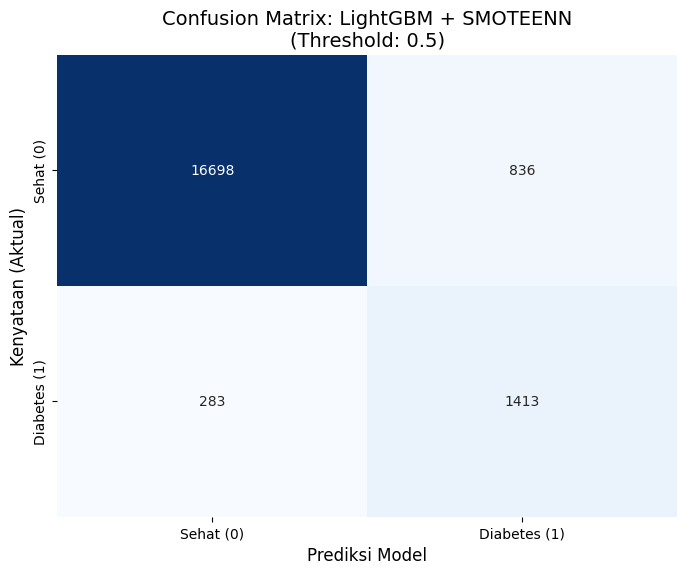


Ringkasan Diagnostik:
✅ True Negatives (Sehat terdeteksi Sehat): 16698
⚠️ False Positives (Sehat dibilang Diabetes): 836
❌ False Negatives (Diabetes Tidak Terdeteksi): 283
⭐ True Positives (Diabetes terdeteksi Diabetes): 1413


In [ ]:
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
custom_threshold = 0.5
y_pred_final = (y_pred_proba >= custom_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Sehat (0)', 'Diabetes (1)'],
            yticklabels=['Sehat (0)', 'Diabetes (1)'])

plt.title(f'Confusion Matrix: LightGBM + SMOTEENN\n(Threshold: {custom_threshold})', fontsize=14)
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Kenyataan (Aktual)', fontsize=12)
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"\nRingkasan Diagnostik:")
print(f"✅ True Negatives (Sehat terdeteksi Sehat): {tn}")
print(f"⚠️ False Positives (Sehat dibilang Diabetes): {fp}")
print(f"❌ False Negatives (Diabetes Tidak Terdeteksi): {fn}")
print(f"⭐ True Positives (Diabetes terdeteksi Diabetes): {tp}")

In [ ]:
!pip install joblib

In [ ]:
import joblib
import json
import os
from google.colab import files

In [ ]:
# --- STEP 1: Simpan Model & Scaler ---
# Kita menyimpan model dan scaler sebagai file binary
print("Menyimpan model dan scaler...")
joblib.dump(final_model, 'lgbm_model.joblib')
joblib.dump(extracted_scaler, 'scaler.joblib')

Menyimpan model dan scaler...


['scaler.joblib']

In [ ]:
metadata = {
    "feature_names": X.columns.tolist(),
    "categorical_mappings": {
        "gender": {'Female': 0, 'Male': 1, 'Other': 2},
        "smoking_history": {'never': 0, 'No Info': 1, 'current': 2, 'former': 3, 'ever': 4, 'not current': 5}
    }
}

with open('metadata.json', 'w') as f:
    json.dump(metadata, f)

In [ ]:
print("Menyiapkan file untuk didownload...")
!zip -r model_fastapi.zip lgbm_model.joblib scaler.joblib metadata.json
files.download('model_fastapi.zip')

print("\n✅ File siap! Gunakan file ini di folder project FastAPI Anda.")

Menyiapkan file untuk didownload...
  adding: lgbm_model.joblib (deflated 60%)
  adding: scaler.joblib (deflated 27%)
  adding: metadata.json (deflated 43%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ File siap! Gunakan file ini di folder project FastAPI Anda.
